<a href="https://colab.research.google.com/github/liam77773smith/cb2330-portfolio/blob/main/Lattice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DPPC fitted theta: 16.5000000000001 kcal/mol
DOPS fitted theta: 6.799999999999984 kcal/mol
DPPC score: 0.2603124999999997
DOPS score: 0.5514285714285714


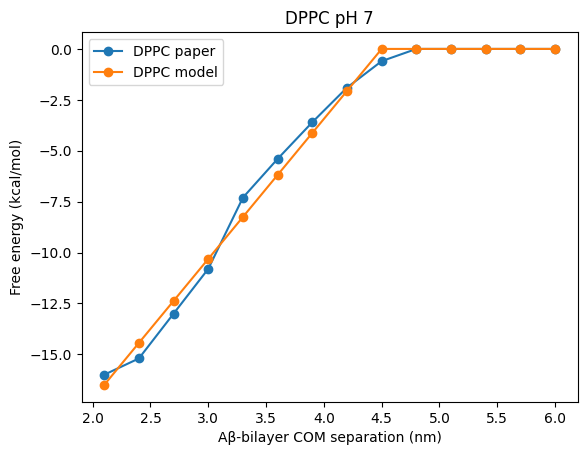

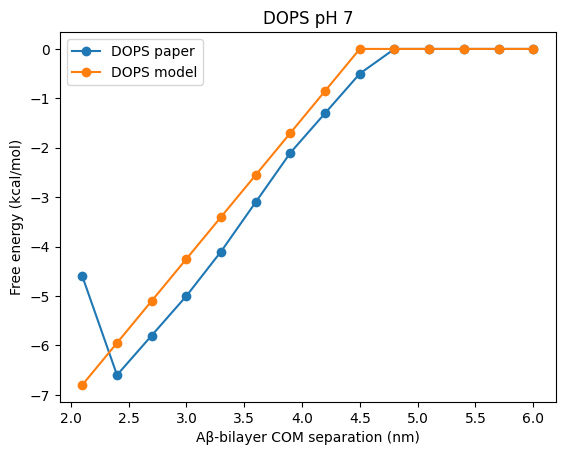

DPPC movement acceptance rate: 0.7546


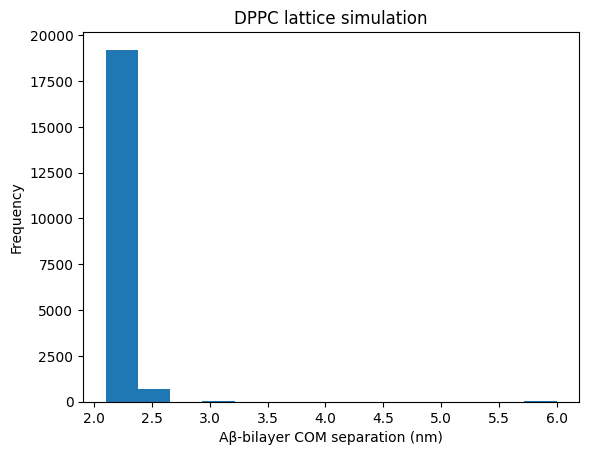

DOPS movement acceptance rate: 0.8129


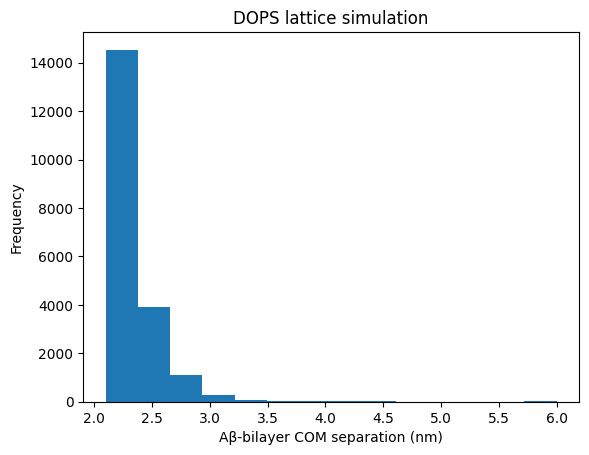

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math


#Random number generator

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32

seed = 30


def lcg(state, a, c, m):
    """The next state of a linear congruential generator."""
    return (a * state + c) % m


#Constants

K_B = 0.001987 #kcal/(mol*K)
T = 323 #Temperature used in the paper

WIDTH = 20

#The paper used 14 COM distances from 2.1 to 6.0 nm
DISTANCES = [2.1, 2.4, 2.7, 3.0, 3.3, 3.6, 3.9,
             4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6.0]

ONSET = 4.5 #Paper states attraction starts around 4.5 nm for pH 7
MIN_DISTANCE = 2.1


#Approximate values read from Figure 2.
#These are not exact numbers reported in a table.

DPPC_PH7 = [-16.0, -15.2, -13.0, -10.8, -7.3, -5.4, -3.6,
            -1.9, -0.6, 0.0, 0.0, 0.0, 0.0, 0.0]

DOPS_PH7 = [-4.6, -6.6, -5.8, -5.0, -4.1, -3.1, -2.1,
            -1.3, -0.5, 0.0, 0.0, 0.0, 0.0, 0.0]


#One-parameter energy model

def energy(distance, theta):
    """
    theta = effective binding energy in kcal/mol.

    Energy is 0 before significant membrane attraction begins.
    Below 4.5 nm the energy decreases linearly.
    """

    if distance >= ONSET:
        return 0.0

    fraction = (ONSET - distance) / (ONSET - MIN_DISTANCE)

    return -theta * fraction


def model_profile(theta):
    profile = [0.0] * len(DISTANCES)

    for i in range(len(DISTANCES)):
        profile[i] = energy(DISTANCES[i], theta)

    return profile


#Fit theta backwards to the paper profile

def profile_score(theta, paper_profile):
    model = model_profile(theta)

    total = 0.0

    for i in range(len(paper_profile)):
        difference = model[i] - paper_profile[i]
        total += difference ** 2

    return total / len(paper_profile)


def fit_theta(paper_profile):

    best_theta = None
    best_score = None

    theta = 0.0

    while theta <= 25.0:

        score = profile_score(theta, paper_profile)

        if best_score is None or score < best_score:
            best_score = score
            best_theta = theta

        theta += 0.05

    return best_theta, best_score


theta_dppc, score_dppc = fit_theta(DPPC_PH7)
theta_dops, score_dops = fit_theta(DOPS_PH7)

print("DPPC fitted theta:", theta_dppc, "kcal/mol")
print("DOPS fitted theta:", theta_dops, "kcal/mol")

print("DPPC score:", score_dppc)
print("DOPS score:", score_dops)


#Compare fitted model with paper

plt.plot(DISTANCES, DPPC_PH7, marker="o", label="DPPC paper")
plt.plot(DISTANCES, model_profile(theta_dppc),
         marker="o", label="DPPC model")

plt.xlabel("Aβ-bilayer COM separation (nm)")
plt.ylabel("Free energy (kcal/mol)")
plt.title("DPPC pH 7")
plt.legend()
plt.show()


plt.plot(DISTANCES, DOPS_PH7, marker="o", label="DOPS paper")
plt.plot(DISTANCES, model_profile(theta_dops),
         marker="o", label="DOPS model")

plt.xlabel("Aβ-bilayer COM separation (nm)")
plt.ylabel("Free energy (kcal/mol)")
plt.title("DOPS pH 7")
plt.legend()
plt.show()


#One Metropolis movement on the lattice

def metropolis_step(x, y, theta, state):

    #Choose one of four directions
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state / M_LCG

    direction = int(4 * r)

    new_x = x
    new_y = y

    if direction == 0: #left
        new_x = (x - 1) % WIDTH

    elif direction == 1: #right
        new_x = (x + 1) % WIDTH

    elif direction == 2: #towards membrane
        if y > 0:
            new_y = y - 1

    elif direction == 3: #away from membrane
        if y < len(DISTANCES) - 1:
            new_y = y + 1


    old_energy = energy(DISTANCES[y], theta)
    new_energy = energy(DISTANCES[new_y], theta)

    delta_energy = new_energy - old_energy


    #Energy-favourable moves are always accepted
    if delta_energy <= 0:
        return new_x, new_y, state, 1


    #Energy-unfavourable moves are accepted probabilistically
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state / M_LCG

    probability = math.exp(-delta_energy / (K_B * T))

    if r < probability:
        return new_x, new_y, state, 1


    #Rejected movement
    return x, y, state, 0


#Forward lattice simulation

def lattice_simulation(theta, state, n_steps=20000):

    x = WIDTH // 2

    #Start in solution at 6.0 nm
    y = len(DISTANCES) - 1

    trajectory = [0.0] * n_steps

    n_acc = 0

    for t in range(n_steps):

        x, y, state, accepted = metropolis_step(
            x, y, theta, state
        )

        n_acc += accepted

        trajectory[t] = DISTANCES[y]

    return trajectory, n_acc, state


#Forward simulation using fitted DPPC interaction

state = seed

trajectory_dppc, n_acc_dppc, state = lattice_simulation(
    theta_dppc,
    state
)

print("DPPC movement acceptance rate:",
      n_acc_dppc / len(trajectory_dppc))


plt.hist(trajectory_dppc, bins=14)
plt.xlabel("Aβ-bilayer COM separation (nm)")
plt.ylabel("Frequency")
plt.title("DPPC lattice simulation")
plt.show()


#Forward simulation using fitted DOPS interaction

state = seed

trajectory_dops, n_acc_dops, state = lattice_simulation(
    theta_dops,
    state
)

print("DOPS movement acceptance rate:",
      n_acc_dops / len(trajectory_dops))


plt.hist(trajectory_dops, bins=14)
plt.xlabel("Aβ-bilayer COM separation (nm)")
plt.ylabel("Frequency")
plt.title("DOPS lattice simulation")
plt.show()